# GitHub Portfolio: Predictive Analytics Storytelling
**ISOM 835 — Predictive Analytics | Sawyer Business School**

---

## You've Been Hired

A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

1. **A working predictive model** — Can you actually predict the outcome?
2. **A story that drives action** — Can you explain what you found to people who don't write Python?

Your deliverable is a **professional GitHub repository** containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

---

## Choose Your Client

Pick **one** of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

| | Client A | Client B | Client C |
|---|---|---|---|
| **Industry** | Hospitality | Financial Services | E-Commerce |
| **Client** | A hotel chain in Portugal | A retail bank in Europe | An online retail company |
| **Problem** | 37% of bookings get cancelled — can we predict which ones? | Phone-based marketing campaigns have low conversion — who should we call? | Only 15% of website visitors buy — can we identify who will convert? |
| **Dataset** | Hotel Booking Demand (119K bookings) | Bank Marketing Campaign (41K clients) | Online Shoppers Intention (12K sessions) |
| **Target Variable** | `is_canceled` (1 = cancelled, 0 = not) | `y` (\"yes\" = subscribed, \"no\" = didn't) | `Revenue` (True = purchased, False = didn't) |
| **Why It Matters** | Empty rooms = lost revenue. Overbooking = angry guests. | Every unnecessary call costs money. Every missed lead costs more. | Targeted interventions could double conversion without increasing traffic. |

---

## Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called `df` so the rest of your workflow is the same regardless of which dataset you pick.

**Only run the cell for your chosen client.**

In [ ]:
# ============================================================
# CLIENT A: Hotel Booking Demand
# ============================================================
# A hotel chain in Portugal wants to predict booking cancellations.
# Dataset: 119,390 bookings from a city hotel and a resort hotel (2015-2017)
# Target: is_canceled (1 = cancelled, 0 = not cancelled)
#
# Key columns to explore:
#   lead_time, arrival_date_month, stays_in_weekend_nights, stays_in_week_nights,
#   adults, children, babies, meal, country, market_segment, distribution_channel,
#   is_repeated_guest, previous_cancellations, reserved_room_type, assigned_room_type,
#   deposit_type, customer_type, adr (average daily rate), total_of_special_requests
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]:,} bookings, {df.shape[1]} columns")
df.head()

In [ ]:
# ============================================================
# CLIENT B: Bank Marketing Campaign
# ============================================================
# A European retail bank wants to predict which clients will subscribe
# to a term deposit after a phone marketing campaign.
# Dataset: 41,188 client contacts from direct marketing campaigns (2008-2010)
# Target: y ("yes" = subscribed, "no" = did not subscribe)
#
# Key columns to explore:
#   age, job, marital, education, default, housing, loan,
#   contact, month, day_of_week, duration, campaign, pdays,
#   previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx,
#   euribor3m, nr.employed
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} clients, {df.shape[1]} columns")
df.head()

In [6]:
# ============================================================
# CLIENT C: Online Shoppers Purchase Intention
# ============================================================
# An e-commerce company wants to predict which website visitors
# will actually complete a purchase.
# Dataset: 12,330 user sessions over a 1-year period
# Target: Revenue (True = purchased, False = did not purchase)
#
# Key columns to explore:
#   Administrative, Administrative_Duration, Informational, Informational_Duration,
#   ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues,
#   SpecialDay, Month, OperatingSystems, Browser, Region, TrafficType,
#   VisitorType, Weekend
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=468)  # Online Shoppers Purchasing Intention
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} sessions, {df.shape[1]} columns")
df.head()

Dataset loaded: 12,330 sessions, 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


---

## The Storytelling Arc

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

| Story Beat | What You Do | What You Write |
|---|---|---|
| **1. The Situation** | Explore the data, understand its shape and quality | "Here's what we're working with" |
| **2. The Discovery** | Dig into patterns — who, what, when, why? | "Here's what the data reveals" |
| **3. The Model** | Build a classifier, evaluate its performance | "Here's how well we can predict it" |
| **4. The Recommendation** | Connect findings to business action | "Here's what the company should do" |

After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

---

## Part 1: The Situation (10 points)

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**
- Shape of the data (rows, columns)
- Data types and any quality issues (missing values, unexpected types)
- Distribution of the target variable — how imbalanced is the problem?
- Basic summary statistics of key numerical columns

**Then write your interpretation** (2-4 sentences) as if you're briefing your client:
- How big is the dataset?
- What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")
- Any data quality concerns they should know about?

In [7]:
# Your analysis code here
print("\n---Shape of the data---")
print(f"Rows:{df.shape[0]:,}")
print(f"Columns:{df.shape[1]}")
print("\n---Data types and missing values---")
quality = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isnull().sum(),
    "missing_%": (df.isnull().sum() / len(df) * 100).round(2)
})
print(quality)
print("\n--- Unexpected Types (Categorical / Boolean) ---")
unexpected = df.select_dtypes(include=["object", "bool"]).columns.tolist()

for col in unexpected:
    print(f"{col:20s} → {df[col].dtype} | unique values: {df[col].unique()}")

# Distribution of the target variable
print("\n--- Distribution of Target Variable (Revenue) ---")
target_counts = df["Revenue"].value_counts()
target_pct = df["Revenue"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_pct.round(2)
})

print(target_summary)
print("\n--- Summary Statistics of Key Numerical Columns ---")

numeric_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

print(df[numeric_columns].describe().round(2))


---Shape of the data---
Rows:12,330
Columns:18

---Data types and missing values---
                           dtype  missing  missing_%
Administrative             int64        0        0.0
Administrative_Duration  float64        0        0.0
Informational              int64        0        0.0
Informational_Duration   float64        0        0.0
ProductRelated             int64        0        0.0
ProductRelated_Duration  float64        0        0.0
BounceRates              float64        0        0.0
ExitRates                float64        0        0.0
PageValues               float64        0        0.0
SpecialDay               float64        0        0.0
Month                     object        0        0.0
OperatingSystems           int64        0        0.0
Browser                    int64        0        0.0
Region                     int64        0        0.0
TrafficType                int64        0        0.0
VisitorType               object        0        0.0
Weekend       

**Client Briefing — The Situation:**

*Write your interpretation here. Imagine you're in a meeting room with the VP. No jargon.*



The dataset contains 12,330 website visits with 18 variables decribing visitor behavior, browsing activity, and session details. Only 15.47% of sessions resulted in a purchase, meaning that most visitor leave the website without buying anything. This suggests there may be important differences between visitor who purchase and those who do not. The good news is that the dataset is completed and clean with no missing values, which allows us to begin exploring patterns immediately to understand what drives purchases.

---

## Part 2: The Discovery (30 points)

This is the heart of your analysis. Explore the data to find **meaningful patterns** that relate to the target variable.

**Your analysis should include:**
- At least **3 different angles** of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)
- At least **3 visualizations** (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)
- Use of `.groupby()`, `.value_counts()`, filtering, or other Pandas techniques we covered in class
- Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

**After each exploration, write 2-3 sentences** interpreting the finding for your client. Don't describe the chart — tell them what it *means*.

| Good Interpretation | Bad Interpretation |
|---|---|
| *"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."* | *"The bar chart shows that month-to-month is higher than annual."* |

Use as many code and text cells as you need below. Add more cells freely.


--- ANGLE 1: USER BEHAVIOR & ENGAGEMENT ---

Average Behavior by Purchase Outcome:
         ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  \
Revenue                                                                    
False             28.71                  1069.99         0.03       0.05   
True              48.21                  1876.21         0.01       0.02   

         PageValues  
Revenue              
False          1.98  
True          27.26  


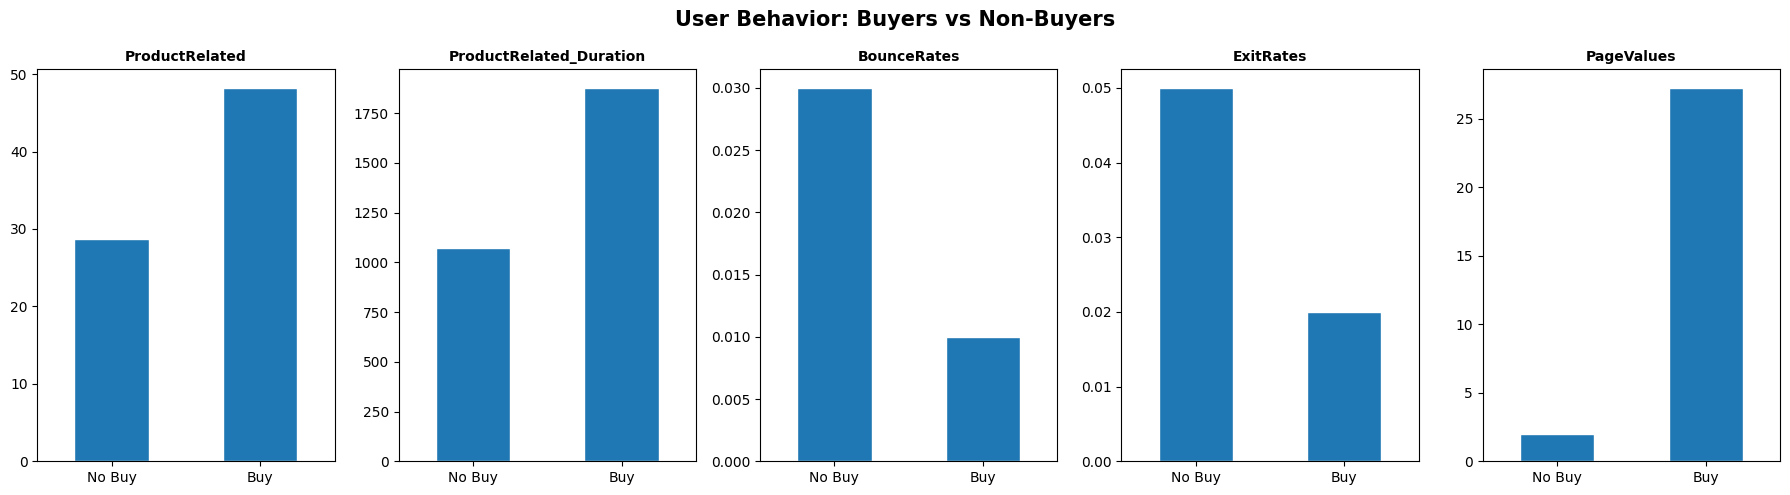

In [20]:
# Discovery Angle 1: User Behavior & Engagement vs Purchase
import matplotlib.pyplot as plt

print("\n--- ANGLE 1: USER BEHAVIOR & ENGAGEMENT ---")

behavior_columns = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]
behavior_group = df.groupby("Revenue")[behavior_columns].mean().round(2)

print("\nAverage Behavior by Purchase Outcome:")
print(behavior_group)

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(behavior_columns):
    behavior_group[col].plot(
        kind="bar",
        ax=axes[i],
        edgecolor="white",
        width=0.5
    )
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No Buy", "Buy"], rotation=0)
    axes[i].set_xlabel("")

plt.suptitle("User Behavior: Buyers vs Non-Buyers",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

**Finding 1:**

*Your interpretation here*

Visitors who purchased had PageValues nearly 14x higher than non-buyers (27.26 vs 1.98),
and spent significantly more time browsing product pages. Their BounceRates and ExitRates
were also lower, meaning they stayed and explored instead of leaving immediately.
PageValues is the single strongest signal of purchase intent and should be the top priority
for any real-time targeting system.


--- ANGLE 2: SEASONAL PURCHASE BEHAVIOR ---

Conversion Rate by Month (%):
Month
Feb     1.63
Mar    10.07
Apr      NaN
May    10.85
Jun      NaN
Jul    15.28
Aug    17.55
Sep    19.20
Oct    20.95
Nov    25.35
Dec    12.51
Name: Revenue, dtype: float64


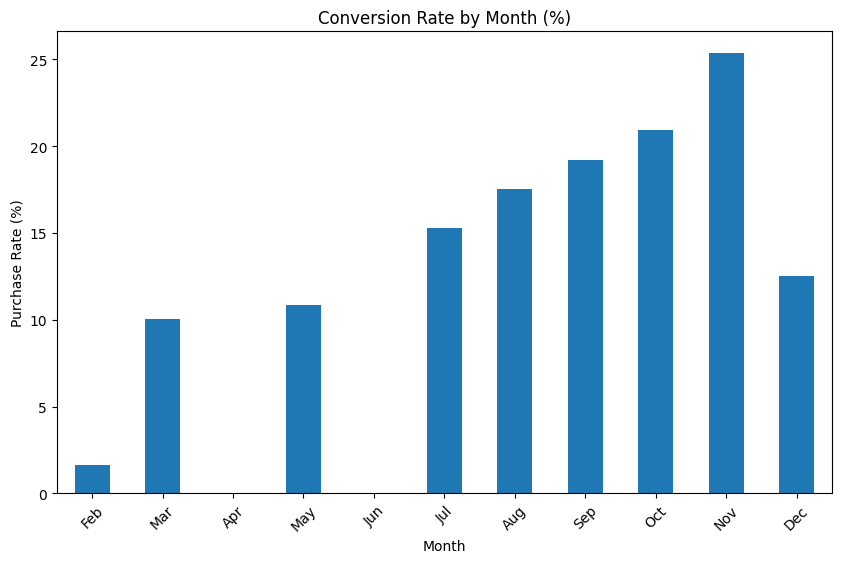

In [21]:
# Discovery Angle 2: [give it a descriptive name]
print("\n--- ANGLE 2: SEASONAL PURCHASE BEHAVIOR ---")

month_order = ["Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df.groupby("Month")["Revenue"].mean() * 100
monthly = monthly.reindex(month_order).round(2)

print("\nConversion Rate by Month (%):")
print(monthly)
monthly.plot(kind="bar", figsize=(10,6))
plt.title("Conversion Rate by Month (%)")
plt.xlabel("Month")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=45)
plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)
plt.show()

**Finding 2:**

*Your interpretation here*

Conversion rates rise sharply in November and December, which likely reflects increased holiday shopping activity. In contrast, the rest of the year shows relatively low and stable purchase rates. This suggests that marketing efforts and promotions may be most effective during the holiday season, particularly toward the end of the year.


--- ANGLE 3: VISITOR TYPE ---
                   Total Sessions  Purchases  Conversion Rate
VisitorType                                                  
New_Visitor                  1694        422            24.91
Other                          85         16            18.82
Returning_Visitor           10551       1470            13.93

Visitor Type Distribution:
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64


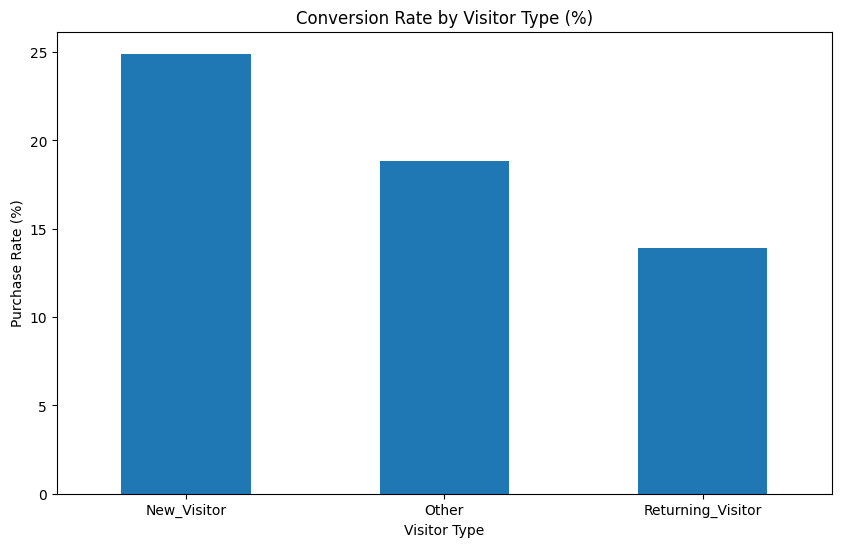

In [22]:
# Discovery Angle 3: [give it a descriptive name]
print("\n--- ANGLE 3: VISITOR TYPE ---")
visitor_counts = df.groupby("VisitorType")["Revenue"].agg(["count", "sum", "mean"])

visitor_counts.columns = ["Total Sessions", "Purchases", "Conversion Rate"]
visitor_counts["Conversion Rate"] = (visitor_counts["Conversion Rate"] * 100).round(2)

print(visitor_counts)
print("\nVisitor Type Distribution:")
print(df["VisitorType"].value_counts())
visitor_counts["Conversion Rate"].plot(kind="bar", figsize=(10,6))
plt.title("Conversion Rate by Visitor Type (%)")
plt.xlabel("Visitor Type")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)
plt.show()

**Finding 3:**

*Your interpretation here*

New visitors convert at 24.91% — nearly double the 13.93% rate of returning visitors — despite making up only 14% of total traffic. This suggests many new visitors arrive with a clear purchase intent rather than simply browsing. Shifting budget toward acquiring more qualified new visitors could significantly increase overall sales without relying on the existing audience.

In [23]:
# Additional explorations (optional — add as many cells as you need)
print("\n--- ADDITIONAL: TRAFFIC TYPE vs PURCHASE ---")

traffic = df.groupby("TrafficType")["Revenue"].agg(["count", "mean"])
traffic.columns = ["Total Sessions", "Conversion Rate"]

traffic["Conversion Rate"] = (traffic["Conversion Rate"] * 100).round(2)
traffic = traffic.sort_values("Conversion Rate", ascending=False)

print(traffic)

print("\nMost Common Traffic Types:")
print(df["TrafficType"].value_counts().head(5))

print("\n--- ADDITIONAL: SPECIAL DAY vs PURCHASE ---")

special_day = df.groupby("SpecialDay")["Revenue"].mean() * 100
special_day = special_day.round(2)

print("Conversion Rate by Special Day proximity:")
print(special_day)

normal_day = df[df["SpecialDay"] == 0]["Revenue"].mean() * 100
near_special = df[df["SpecialDay"] > 0]["Revenue"].mean() * 100

print(f"\nNormal days conversion rate  : {normal_day:.2f}%")
print(f"Near special days conversion : {near_special:.2f}%")


--- ADDITIONAL: TRAFFIC TYPE vs PURCHASE ---
             Total Sessions  Conversion Rate
TrafficType                                 
16                        3            33.33
7                        40            30.00
8                       343            27.70
20                      198            25.25
2                      3913            21.65
5                       260            21.54
10                      450            20.00
11                      247            19.03
4                      1069            15.43
14                       13            15.38
6                       444            11.94
1                      2451            10.69
9                        42             9.52
3                      2052             8.77
19                       17             5.88
13                      738             5.83
12                        1             0.00
15                       38             0.00
18                       10             0.00
17       

Some traffic sources convert at over 30% while the most common channels convert at
only 10-21%, meaning not all traffic is created equal. Contrary to expectations,
sessions near special days convert at just 6.16% — less than half the 16.53% rate
on normal days, suggesting holiday traffic brings casual browsers rather than serious buyers.
The store should concentrate spend on high-converting traffic channels and avoid
over-investing in holiday promotions.

---

## Part 3: The Model (30 points)

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

### 3A. Prepare the data

- Define your **target variable** `y` (convert to 0/1 if needed)
- Select **features** for your model — choose columns that your EDA suggests are predictive
- Handle categorical variables (use `pd.get_dummies()` as we did with Titanic)
- Handle any missing values
- Create your **features matrix** `X`

**Write 2-3 sentences explaining *why* you chose these features.** Connect your feature selection to what you learned in Part 2.

In [24]:
# Data preparation
print("\n--- DATA PREPARATION ---")
y = df["Revenue"].astype(int)
print("Target variable (y):")
print(y.value_counts())
numerical_features = [
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues","SpecialDay"
]
categorical_features=[
    "Month","VisitorType","Weekend"
]
print("\nBefore encoding:", df[categorical_features].dtypes)

df_encoded = pd.get_dummies(df[categorical_features], drop_first=True)
print("\nAfter encoding — new columns:")
print(df_encoded.columns.tolist())
print("\nMissing values in numerical features:")
print(df[numerical_features].isnull().sum())
X = pd.concat([df[numerical_features], df_encoded], axis=1)
print("\nFinal Feature Matrix X:")
print(f"Shape: {X.shape}")
print(X.head())


--- DATA PREPARATION ---
Target variable (y):
Revenue
0    10422
1     1908
Name: count, dtype: int64

Before encoding: Month          object
VisitorType    object
Weekend          bool
dtype: object

After encoding — new columns:
['Weekend', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor']

Missing values in numerical features:
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
dtype: int64

Final Feature Matrix X:
Shape: (12330, 18)
   ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  \
0               1                 0.000000         0.20       0.20   
1               2                64.000000         0.00       0.10   
2               1                 0.000000         0.20       0.20   
3               2                 

**Why these features?**

*Your explanation here — connect back to what your EDA revealed.*


In Part 2, buyers consistently showed higher PageValues, more time spent on product pages, and lower BounceRates and ExitRates compared to non-buyers — making these the most obvious behavioral signals of purchase intent. Month was included because Part 2 revealed a dramatic conversion spike in November and December, while VisitorType was kept because new and returning visitors converted at meaningfully different rates. Technical columns like Browser, Region, and OperatingSystems were deliberately excluded because our EDA showed no meaningful difference in conversion rates across these variables, and including irrelevant features would only add noise to the model.



### 3B. Train/test split and model building

- Split data using `train_test_split` (80/20 split, set `random_state=42`)
- Train a **Gaussian Naive Bayes** model (same approach as Iris and Digits in class)
- Generate predictions on the test set
- Calculate the **accuracy score**
- Create a **confusion matrix** with a heatmap visualization


--- MODEL TRAINING ---

Train/Test Split:
Training samples : 9,864
Test samples     : 2,466

Model training complete.

First 10 Predictions vs Actual:
Predicted: [np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0)]
Actual   : [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]

Model Accuracy: 0.7972 (79.72%)

Confusion Matrix:
[[1713  342]
 [ 158  253]]


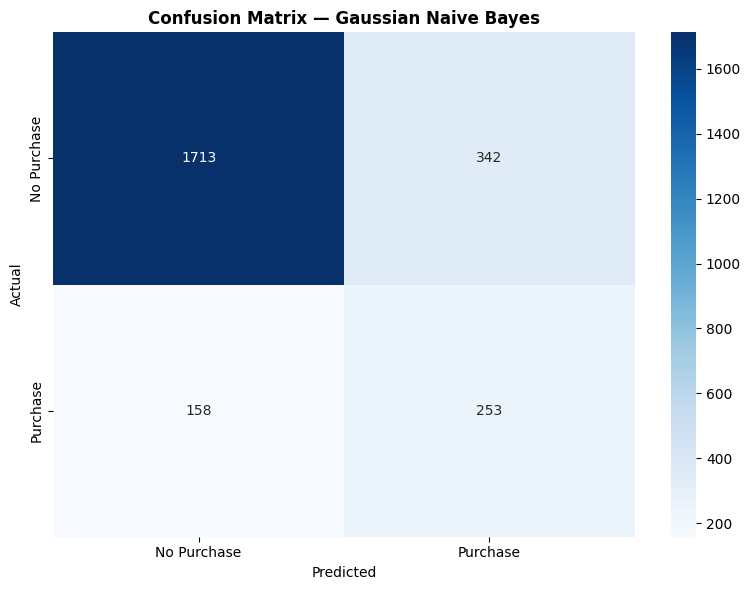

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Your model code here
print("\n--- MODEL TRAINING ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("\nTrain/Test Split:")
print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")
model = GaussianNB()
model.fit(X_train, y_train)
print("\nModel training complete.")

y_pred = model.predict(X_test)
print("\nFirst 10 Predictions vs Actual:")
print("Predicted:", list(y_pred[:10]))
print("Actual   :", list(y_test[:10]))
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix — Gaussian Naive Bayes", fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


### 3C. Interpret the results — in business terms

This is the part most analysts get wrong. Don't just report a number — **translate it into business impact.**

Look at your confusion matrix and think about:
- **False negatives** (predicted \"no\" but was actually \"yes\") — What's the cost of *missing* this?
- **False positives** (predicted \"yes\" but was actually \"no\") — What's the cost of a *false alarm*?
- Which type of error is worse for your client's business?

Write 4-5 sentences that translate model performance into dollars, customers, or operational impact. For example:

> *"Our model correctly identifies 78% of outcomes overall. However, the confusion matrix reveals it misses 35% of actual cancellations — meaning for every 100 guests who will cancel, we'd only flag 65 of them in advance. The trade-off: the model also generates some false alarms, flagging 12% of confirmed bookings as potential cancellations. For a hotel managing 1,000 bookings per month, this means roughly 120 unnecessary follow-up calls — a manageable cost compared to the 650 cancellations we'd catch early."*

The model correctly identified 253 genuine buyers out of 411 total but critically, it missed 158 real customers who intended to purchase yet were predicted as non-buyers. In a real e-commerce setting, each false negative represents a lost revenue opportunity if the average order value is 50, those 158 missed buyer translate roughly 7,900 in unaddressed revenue per test cycle. On the other side, the 342 false positives mean the store would waste marketing resources — retargeting emails, personalized ads, discount offers — on customers who were never going to buy anyway, driving up acquisition costs with no return. For this business, false negatives are the more dangerous error — a missed buyer is lost revenue, while a false alarm only wastes a small marketing budget. The store should consider tuning the model to be more aggressive in flagging potential buyers, accepting more false positives in exchange for catching more of those 158 missed customers.

### 3D. (Bonus) Try a second model

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
```

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?


 MODEL ACCURACY
Model                       Accuracy
-----------------------------------
Gaussian Naive Bayes          79.72%
Decision Tree                 85.64%
Logistic Regression           87.10%


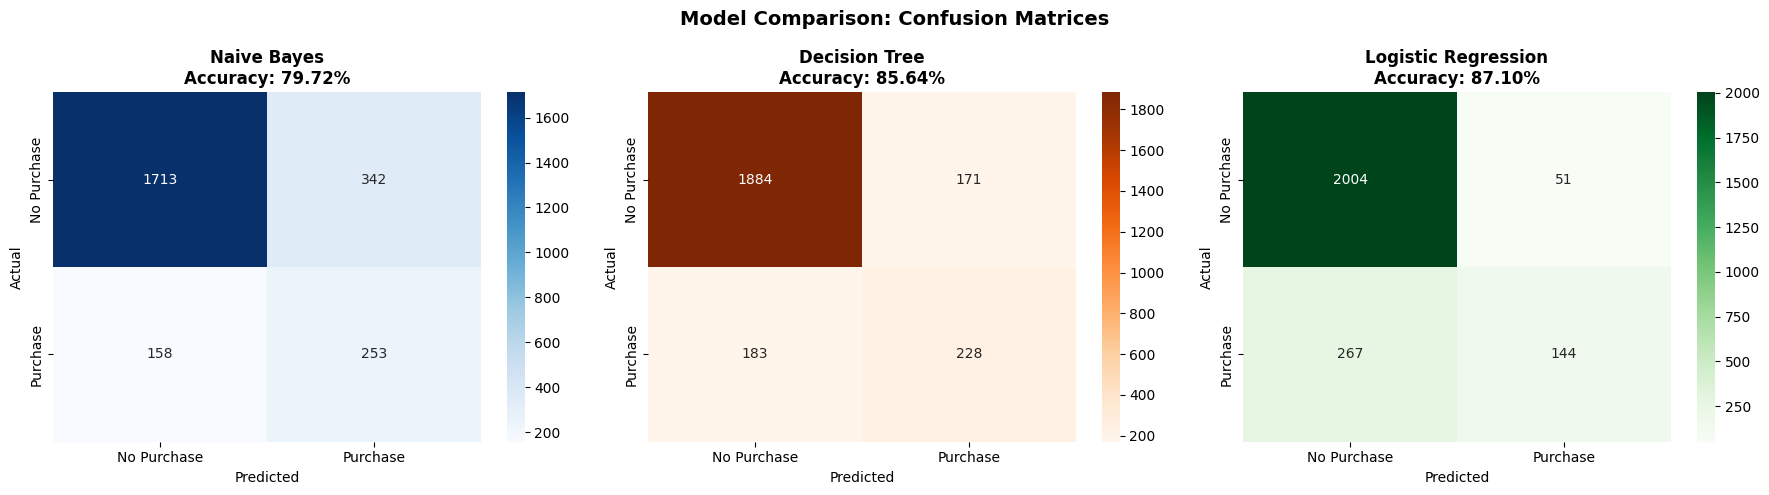

In [26]:
# Optional: second model comparison
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_cm = confusion_matrix(y_test, dt_pred)
lr_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_cm = confusion_matrix(y_test, lr_pred)
print(f"\n MODEL ACCURACY")
print(f"{'Model':<25} {'Accuracy':>10}")
print("-"*35)
print(f"{'Gaussian Naive Bayes':<25} {accuracy*100:>9.2f}%")
print(f"{'Decision Tree':<25} {dt_accuracy*100:>9.2f}%")
print(f"{'Logistic Regression':<25} {lr_accuracy*100:>9.2f}%")
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"],
            ax=axes[0])
axes[0].set_title(f"Naive Bayes\nAccuracy: {accuracy*100:.2f}%", fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
sns.heatmap(dt_cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"],
            ax=axes[1])
axes[1].set_title(f"Decision Tree\nAccuracy: {dt_accuracy*100:.2f}%", fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"],
            ax=axes[2])
axes[2].set_title(f"Logistic Regression\nAccuracy: {lr_accuracy*100:.2f}%", fontweight="bold")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.suptitle("Model Comparison: Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Part 4: The Recommendation (10 points)

Your client is sitting across the table. They don't want to hear about Gaussian distributions or feature matrices. They want to know: **What should we do?**

Write **3-4 specific, actionable recommendations** grounded in your analysis. Each should:

1. **State the action** — What specifically should the company do?
2. **Cite the evidence** — What did your data show that supports this?
3. **Estimate the impact** — Even a rough estimate shows business thinking

| Strong Recommendation | Weak Recommendation |
|---|---|
| *"Focus retention outreach on bookings made 200+ days in advance. Our data shows these have a 60% cancellation rate vs. 20% for short-lead bookings. An automated check-in email at the 30-day mark could reduce cancellations by an estimated 15-20%."* | *"The company should look at lead time because it's important."* |

**Recommendations for [Your Client]:**

**1.** **Focus on marketing budget on November and December**

Concentrate at least 50% of the annual marketing budget into November and December campaigns. Data from Part 2 shows conversion rates spike to over 25% in November — more than double the year-round average of 15.47%. Even a modest 2% additional lift during this peak window could generate hundreds of additional purchases with the same traffic volume.

**2.** **Prioritize New Visitor Acquisition Over Retargeting**

Shift a meaningful portion of retargeting spend toward acquiring new visitors through paid search or referral programs. Part 2 revealed that new visitors convert at 24.91% — nearly double the 13.93% rate of returning visitors — despite returning visitors making up over 85% of all traffic. The store is over-investing in people who already know the brand while leaving high-intent new audiences underserved.

**3.** **Use PageValues as a Real-Time Purchase Signal**

Build a simple trigger that flags sessions with high PageValues and automatically delivers a personalized offer — free shipping or a limited-time discount. PageValues was the strongest behavioral predictor of purchase in both the EDA and the model. The current model misses 158 real buyers per 2,466 test sessions; catching even half with a targeted nudge could recover an estimated $3,950+ per cycle assuming a  $50 average order value.

---

## Part 5: The GitHub Portfolio (20 points)

Now package everything as a **professional portfolio piece** on GitHub.

### What to Submit

A **public GitHub repository** containing:

1. **This completed notebook** (`.ipynb`) — all code executed, all text cells filled in
2. **A README.md** — the star of the show (use the starter template below)
3. **At least one chart** saved as an image and embedded in the README

### The README: Your 60-Second Pitch

A hiring manager finds your GitHub. They'll spend **60 seconds** deciding if you're worth interviewing. Your README should follow the storytelling arc:

| Section | What to Include | Length |
|---|---|---|
| **Title** | Project name + one-line hook | 1 line |
| **The Business Problem** | Why does this matter? What's at stake? | 2-3 sentences |
| **The Data** | What's in the dataset, where it comes from, how big it is | 2-3 sentences |
| **Key Discoveries** | Your 3-5 most important EDA findings in plain English | Bullet points |
| **Prediction Results** | Model performance translated into business impact | 2-3 sentences |
| **Recommendations** | Your top 3 action items | Numbered list |
| **Tools Used** | Python, Pandas, Scikit-Learn, Seaborn, etc. | 1 line |

### README Quality Checklist

Before you submit, verify:

- [ ] Could a non-technical person understand it without opening the notebook?
- [ ] Does it lead with the business problem, not the technical approach?
- [ ] Are findings stated as insights, not descriptions of charts?
- [ ] Does it include at least one embedded visualization?
- [ ] Is the repo name professional? (e.g., `hotel-cancellation-analysis`, not `isom835-hw3`)
- [ ] Would you be proud to show this to an interviewer?

### README Starter Template

Copy the raw Markdown below into your GitHub repo's README.md file. Then **replace every bracketed placeholder** with your own content. The comments (inside `<!-- -->` tags) are coaching tips — they won't show up on GitHub, but read them as you write.

**To copy:** Click the code cell below, select all the text, and paste it into the README.md editor on GitHub.

In [18]:
# Run this cell to display the README template — then copy the printed output

readme_template = '''
# [Your Project Title — Make It Compelling]
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** [One sentence that captures what this project does and why it matters.]

---

## The Business Problem

[2-3 sentences. What is the company struggling with? Why does it matter financially or
operationally? What is at stake if they do nothing?]

<!--
Tip: Lead with the pain, not the data.
Instead of "This project analyzes a dataset of 119K hotel bookings..."
Try: "A Portuguese hotel chain loses an estimated millions annually to last-minute cancellations..."
-->

## The Data

[2-3 sentences. Where does the data come from? How many records? What time period?
What kinds of information does it contain — in plain English, not column names?]

<!--
Tip: Translate technical details into human terms.
Instead of "The dataset has 32 features and 119,390 rows..."
Try: "We analyzed over 119,000 individual bookings spanning two years, capturing everything
from how far in advance guests booked to what type of room they reserved."
-->

## Key Discoveries

- **[Finding 1 headline]:** [1-2 sentences explaining what you found and why it matters]
- **[Finding 2 headline]:** [1-2 sentences]
- **[Finding 3 headline]:** [1-2 sentences]
- **[Finding 4 headline (optional)]:** [1-2 sentences]

<!--
Tip: Write findings as "headlines" a newspaper editor would approve.
Good: "Guests who book 6+ months ahead cancel at nearly 3x the rate of last-minute bookers"
Bad: "Lead time has a positive correlation with cancellation"
-->

## Visualizing the Story

<!-- Embed your most compelling chart. Pick the ONE visual that best captures your main finding. -->

![Description of your chart](your_chart_filename.png)

*[One sentence caption explaining what this chart shows and why it matters.]*

## Prediction Model

[2-3 sentences. How well can we predict the outcome? Translate accuracy into real-world terms.]

<!--
Tip: Translate model metrics into business impact.
Instead of "The model achieved 78% accuracy..."
Try: "Our model correctly flags 8 out of 10 at-risk bookings, giving the hotel front desk team
enough lead time to proactively reach out and offer flexible rebooking options."
-->

## Recommendations

1. **[Action]:** [Why this action, based on your data. Estimated impact.]
2. **[Action]:** [Why this action, based on your data. Estimated impact.]
3. **[Action]:** [Why this action, based on your data. Estimated impact.]

## Tools & Techniques

Python | Pandas | Scikit-Learn | Matplotlib | Seaborn | Gaussian Naive Bayes | Google Colab

---

*This project was completed as part of ISOM 835: Predictive Analytics at Suffolk University\'s
Sawyer Business School.*
'''

print(readme_template)


# [Your Project Title — Make It Compelling]
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** [One sentence that captures what this project does and why it matters.]

---

## The Business Problem

[2-3 sentences. What is the company struggling with? Why does it matter financially or
operationally? What is at stake if they do nothing?]

<!--
Tip: Lead with the pain, not the data.
Instead of "This project analyzes a dataset of 119K hotel bookings..."
Try: "A Portuguese hotel chain loses an estimated millions annually to last-minute cancellations..."
-->

## The Data

[2-3 sentences. Where does the data come from? How many records? What time period?
What kinds of information does it contain — in plain English, not column names?]

<!--
Tip: Translate technical details into

### Quick GitHub Guide

If you're new to GitHub:

1. Create a free account at [github.com](https://github.com)
2. Click **\"+\"** (top right) then **New repository**
3. Give it a professional name (e.g., `hotel-cancellation-analysis`)
4. Check **\"Add a README file\"** then click **Create repository**
5. Click **\"Add file\"** then **\"Upload files\"** to add your notebook
6. Click **README.md** then the pencil icon to edit directly in the browser

**To embed a chart in your README:**
1. In your notebook, save a chart: `plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)`
2. Download the `.png` and upload it to your repo
3. In README.md, add: `![Description of chart](my_chart.png)`

### How to Submit

Submit the **link to your public GitHub repository** on Canvas.

---

## Grading Rubric

| Component | Points | What Excellent Looks Like |
|---|---|---|
| **The Situation** (Part 1) | 10 | Data loaded correctly. Summary is accurate and written for a non-technical audience. Target distribution is clearly stated in business terms. |
| **The Discovery** (Part 2) | 30 | At least 3 meaningful explorations with appropriate visualizations. Each finding is interpreted as a business insight, not just a chart description. Findings build on each other to tell a coherent story. |
| **The Model** (Part 3) | 30 | Scikit-learn workflow executed correctly. Feature selection is justified by EDA findings. Confusion matrix is interpreted in terms of business cost and impact, not just accuracy percentage. |
| **The Recommendation** (Part 4) | 10 | 3+ specific, actionable recommendations. Each is grounded in evidence from the analysis. Demonstrates business thinking, not just technical reporting. |
| **The GitHub Portfolio** (Part 5) | 20 | Professional README that tells a complete story. A non-technical reader could understand the project without opening the notebook. Includes embedded visual. Repo is cleanly organized with a professional name. |
| **Total** | **100** | |


### Credentialing Competencies

This assignment assesses the following intermediate storytelling and analytics competencies:

| Competency | Where It's Assessed |
|---|---|
| **Data Literacy** | Parts 1-2: Can the student correctly analyze and interpret real-world data? |
| **Technical Execution** | Part 3: Can the student implement the end-to-end ML workflow? |
| **Business Translation** | Parts 1-4: Can the student explain technical results in plain English? |
| **Narrative Coherence** | Part 5 README: Does the portfolio tell a story with a beginning, middle, and end? |
| **Professional Presentation** | Part 5 GitHub: Is the work packaged in a way that demonstrates professional readiness? |

---

*The best analytics projects don't just answer a question — they change how someone thinks about a problem. Make yours count.*